In [1]:
import csv
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt  
from ipywidgets import interact, FloatSlider
from datetime import datetime

import os

import numpy as np
from numpy.linalg import solve

import pandas as pd
from scipy.interpolate import BSpline

import seaborn as sns

from scipy.linalg import lstsq

from scipy.stats import pearsonr

import matplotlib.dates as mdates

import importlib
import function
importlib.reload(function)
from function import *

# Fonctions

## Régression Régionale

In [2]:

ALPHA = 3.0   # Mallows Cp (3=Kooperberg, 2=AIC, log(n)=BIC)


def run_regional_spline(ts: pd.DataFrame, use_mallows: bool = True) -> dict:
    """
    Ajustement régional par B-spline pénalisée.

    Paramètres
    ----------
    ts           : DataFrame avec colonnes 'date' (datetime) et 'mean_value'
    use_mallows  : True  → sélection du nombre de nœuds via critère Mallows Cp
                   False → n_knots = nombre de points du signal

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat, history
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)

    print(f"  n = {len(values)}")

    # Sélection du nombre de nœuds
    if use_mallows:
        print(f"  Selection of the number of knots (alpha={ALPHA}) ...\n")
        n_knots, history = stepwise_knot_selection_bspline(t_numeric, values, alpha=ALPHA)
    else:
        n_knots = len(ts)
        history = None
        print(f"  n_knots fixed by number of points : {n_knots}\n")

    std_reg = np.std(values)

    B        = build_bspline_basis(t_numeric, n_knots)
    lam_opt  = optimize_lambda_gcv(B, values)
    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # Graphe 1 : critère Cp (uniquement si Mallows)
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    if use_mallows:
        plt.figure(figsize=(14, 5))
        plt.plot(history["n_knots"], history["Cp"], "o-", color="steelblue", linewidth=2)
        plt.axvline(n_knots, color="tomato", linestyle="--",
                    label=f"Optimal : {n_knots} nœuds")
        plt.xlabel("Number of knots")
        plt.ylabel("Mallows $C_p$")
        plt.title("Mallows’ selection criterion $C_p$")
        plt.gca().invert_xaxis()
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # Graphe 2 : ajustement final
    mode_label = f"Mallows Cp | n_knots={n_knots}" if use_mallows else f"n_knots={n_knots} (nb points)"

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Original Signal")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Optimal Spline | {mode_label} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Backscatter (dB)")
    plt.title("Regional Spline")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "Y_hat"    : Y_hat,
        "reg_std"  : std_reg,
        "history"  : history,   # None si use_mallows=False
    }


## Régression Locale version classique

In [3]:

def run_local_spline_classic(ts: pd.DataFrame,lam_regional,std_regional,condition_cgv) -> dict:
    """
    Ajustement local par B-spline pénalisée avec n_knots = len(ts).

    Paramètre
    ---------
    ts : DataFrame avec colonnes 'date' (datetime) et 'mean_value'

    Retourne
    --------
    dict avec : dates, values, t_numeric, n_knots, lam, Y_hat
    """
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)
    n_knots   = len(ts)

    
    std_loc = np.std(values)

    B        = build_bspline_basis(t_numeric, n_knots)
    if condition_cgv==True: 
        lam_opt  = optimize_lambda_gcv(B, values)
    else: 
        lam_opt = (std_loc / std_regional)**(2) * lam_regional
        #lam_opt = ((std_regional - std_loc)/ std_loc) * lam_regional

    _, Y_hat = penalized_spline_fit(B, values, lam_opt)

    # — Graphe : ajustement local —
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Original Signal")
    plt.plot(dates_dt, Y_hat, color='tomato', linewidth=2.5,
             label=f"Local Spline | n_knots={n_knots} | λ={lam_opt:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Backscatter (dB)")
    plt.title("Local Spline")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "std_err"  : std_loc,
        "Y_hat"    : Y_hat,
    }




## Régression Locale comparaison CGV

In [4]:
def run_local_spline(ts: pd.DataFrame, lam_regional, std_regional, condition_cgv) -> dict:
    dates    = ts["date"].values
    values   = ts["mean_value"].values
    dates_dt = pd.to_datetime(dates)

    t_numeric = np.array([(d - dates_dt[0]).days for d in dates_dt], dtype=float)
    n_knots   = len(ts)
    std_loc   = np.std(values)

    B = build_bspline_basis(t_numeric, n_knots)

    # — Spline GCV —
    lam_gcv     = optimize_lambda_gcv(B, values)
    _, Y_hat_gcv = penalized_spline_fit(B, values, lam_gcv)

    # — Spline λ regional —
    lam_reg      = (std_loc / std_regional) ** 2 * lam_regional
    _, Y_hat_reg = penalized_spline_fit(B, values, lam_reg)

    # — Graphe —
    sns.set_style("whitegrid")
    plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "legend.fontsize": 12})

    plt.figure(figsize=(14, 5))
    plt.plot(dates_dt, values, '-o', color='tab:blue', alpha=0.45,
             linewidth=1.5, markersize=5, label="Original Signal")
    plt.plot(dates_dt, Y_hat_gcv, color='tomato', linewidth=2.5,
             label=f"Spline GCV | λ={lam_gcv:.2e}")
    plt.plot(dates_dt, Y_hat_reg, color='seagreen', linewidth=2.5, linestyle='--',
             label=f"Spline λ regional | λ={lam_reg:.2e}")
    plt.xlabel("Date")
    plt.ylabel("Backscatter (dB)")
    plt.title(f"Local Spline | n_knots={n_knots}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # — Retour selon condition_cgv —
    if condition_cgv:
        lam_opt, Y_hat = lam_gcv, Y_hat_gcv
    else:
        lam_opt, Y_hat = lam_reg, Y_hat_reg

    return {
        "dates"    : dates_dt,
        "values"   : values,
        "t_numeric": t_numeric,
        "n_knots"  : n_knots,
        "lam"      : lam_opt,
        "std_err"  : std_loc,
        "Y_hat"    : Y_hat,
    }

# Cas de Trinité
Nous choisissons d'utiliser la première sous-zone en tant que modèle régional avec la polarisation DES soit une orbite 39. 

## Données

### Données régionales

In [5]:

FILEPATHS_regional = {
    "vv": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vv_ASC_120_867km2.csv",
    "vh": "data/Data/StudyCase_S1_Trinité/ts_s1a_21NZF_vh_ASC_120_867km2.csv",
}

def extract_signal_regional(polarization, masking="masked"):
    """
    Extrait la série temporelle depuis les fichiers CSV S1A.

    Args:
        polarization (str): "vv" ou "vh"
        masking (str):       "masked" ou "unmasked"

    Returns:
        pd.DataFrame: colonnes ["date", "mean_value"], triées par date
    """
    polarization = polarization.lower()
    masking = masking.lower()

    if polarization not in FILEPATHS_regional:
        raise ValueError(f"polarization doit être 'vv' ou 'vh', reçu : '{polarization}'")
    if masking not in ("masked", "unmasked"):
        raise ValueError(f"masking doit être 'masked' ou 'unmasked', reçu : '{masking}'")

    col = f"moy_{masking}"

    df = pd.read_csv(FILEPATHS_regional[polarization])
    df["date"] = pd.to_datetime(df["date"])

    return (
        df[["date", col]]
        .rename(columns={col: "mean_value"})
        .sort_values("date")
        .reset_index(drop=True)
    )

### Données locales

| Subzone    | Nombre de pixels |
|------------|-----------------|
| subzone1   | 3256            |
| subzone2   | 2862            |
| subzone3   | 2496            |
| subzone4   | 432             |
| subzone5   | 900             |
| subzone6   | 340             |
| subzone7   | 255             |
| subzone8   | 270             |
| subzone9   | 2116            |
| subzone10  | 210             |

##### Modalités disponibles

| Paramètre       | Valeurs possibles                        |
|:----------------|:-----------------------------------------|
| `subzone`       | `1` `2` `3` `4` `5` `6` `7` `8` `9` `10` |
| `type_veg`      | `"fol"` `"defol"` `"nodata"`             |
| `polarization`  | `"vh"` `"vv"`                            |
| `orbite`        | `39` `120`                               |
| `direction`     | `"ASC"` `"DES"`                          |
| `satellite`     | `"s1a"` `"s1b"` `"s1c"`                  |

In [6]:
FILEPATH_local = "data/Data/StudyCase_S1_Trinité/ts_10subzones_defoliated.csv"

def extract_signal_local_log(subzone, type_veg, polarization, orbite, direction, satellite=None):
    def to_list(val):
        return [val] if not isinstance(val, list) else val

    df = pd.read_csv(FILEPATH_local)
    df["subzone_id"] = df["shapefile_name"].str.extract(r"subzone(\d+)").astype(int)

    mask = (
        df["subzone_id"].isin(to_list(subzone)) &
        df["type"].isin(to_list(type_veg)) &
        df["polarization"].isin(to_list(polarization)) &
        df["orbite"].isin(to_list(orbite)) &
        df["direction"].isin(to_list(direction))
    )
    if satellite is not None:
        mask &= df["satellite"].isin(to_list(satellite))

    df_filtered = df[mask].copy()
    df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="%Y%m%d")
    df_filtered["mean_value"] = 10 * np.log10(df_filtered["mean_value"])

    return df_filtered[["date", "mean_value"]].sort_values("date").reset_index(drop=True)

## Splines Régression

### Splines Regionales

  n = 262
  n_knots fixed by number of points : 262



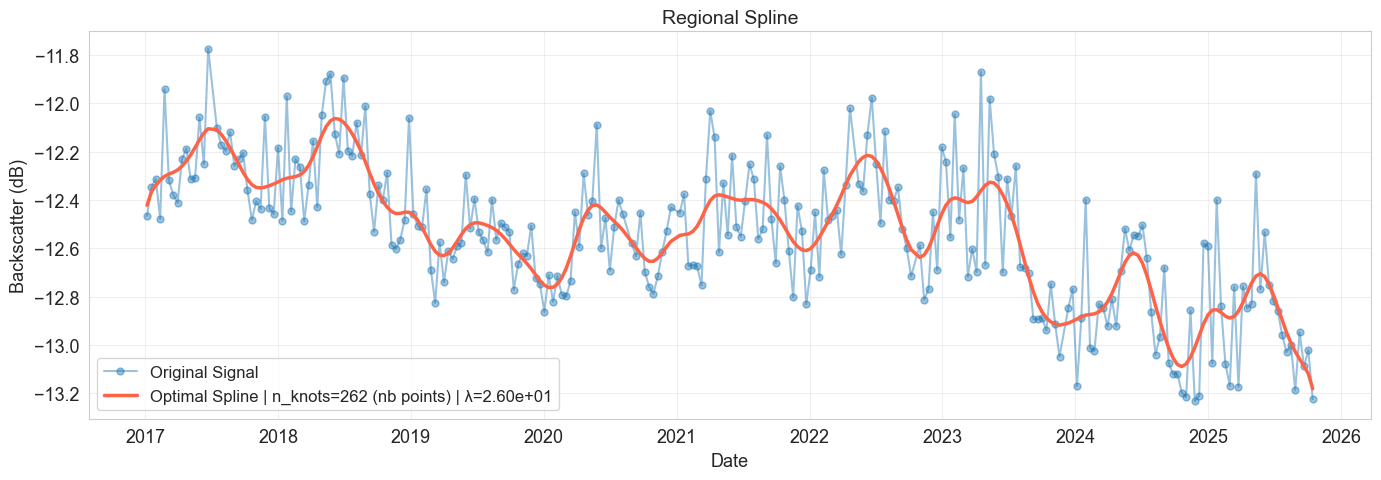

  n = 262
  n_knots fixed by number of points : 262



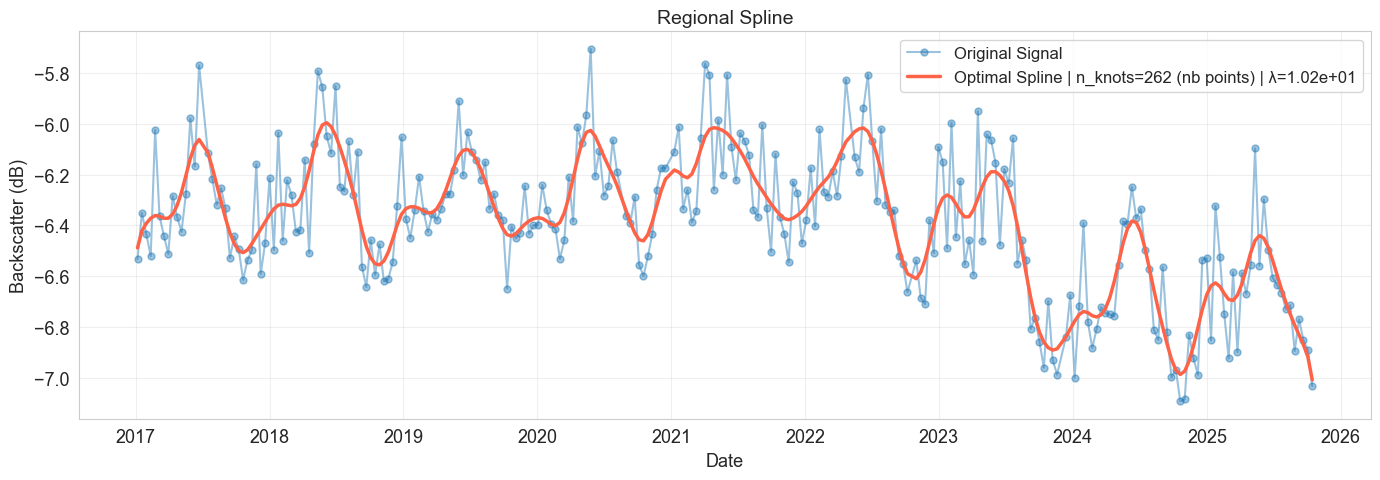

  n = 266
  n_knots fixed by number of points : 266



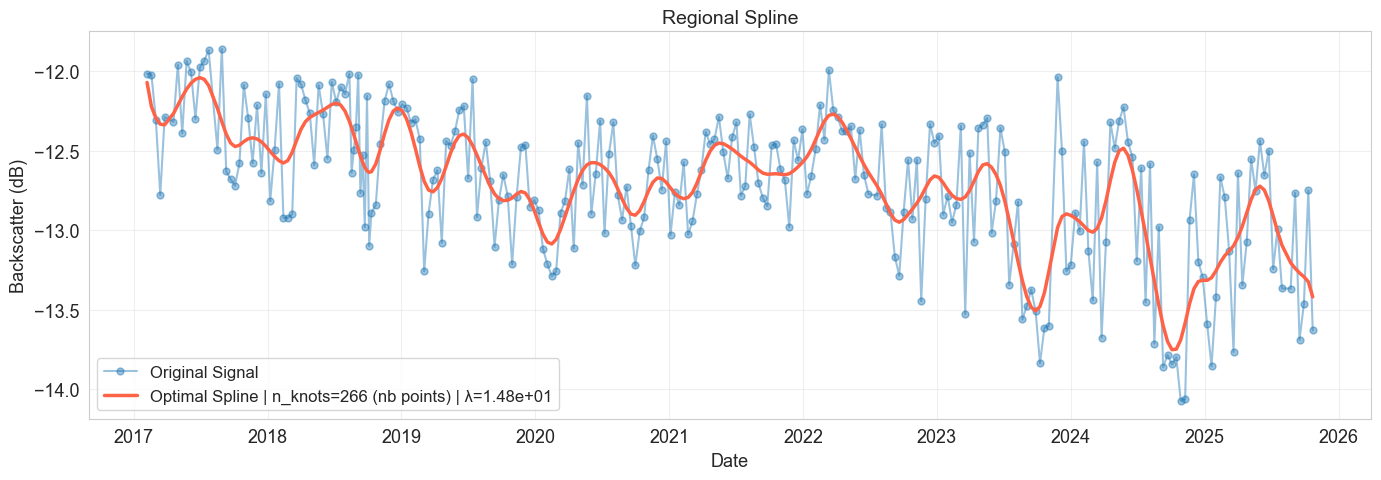

In [7]:
# VV masqué
ts_regional_vv_masked = extract_signal_regional("vv", "masked")

# VH non masqué
ts_regional_vh_masked = extract_signal_regional("vh", "masked")

# Zone 1
ts_defol_z1_vh     = extract_signal_local_log(subzone=1, type_veg="defol", polarization="vh", orbite=39, direction="DES")

# spline
result_regional_vh = run_regional_spline(ts_regional_vh_masked,use_mallows=False)   # sélection Cp automatique
result_regional_vv = run_regional_spline(ts_regional_vv_masked,use_mallows=False)   
result_regional_zone1=run_regional_spline(ts_defol_z1_vh ,use_mallows=False)

# paramètres pour regression locale
## VH
lambda_regional_vh=result_regional_vh["lam"]
std_regional_vh= result_regional_vh["reg_std"]

## VV
lambda_regional_vv=result_regional_vv["lam"]
std_regional_vv= result_regional_vv["reg_std"]

## Zone 1
lambda_regional_zone1=result_regional_zone1["lam"]
std_regional_zone1= result_regional_zone1["reg_std"]


### Splines Locales

#### Zone 1

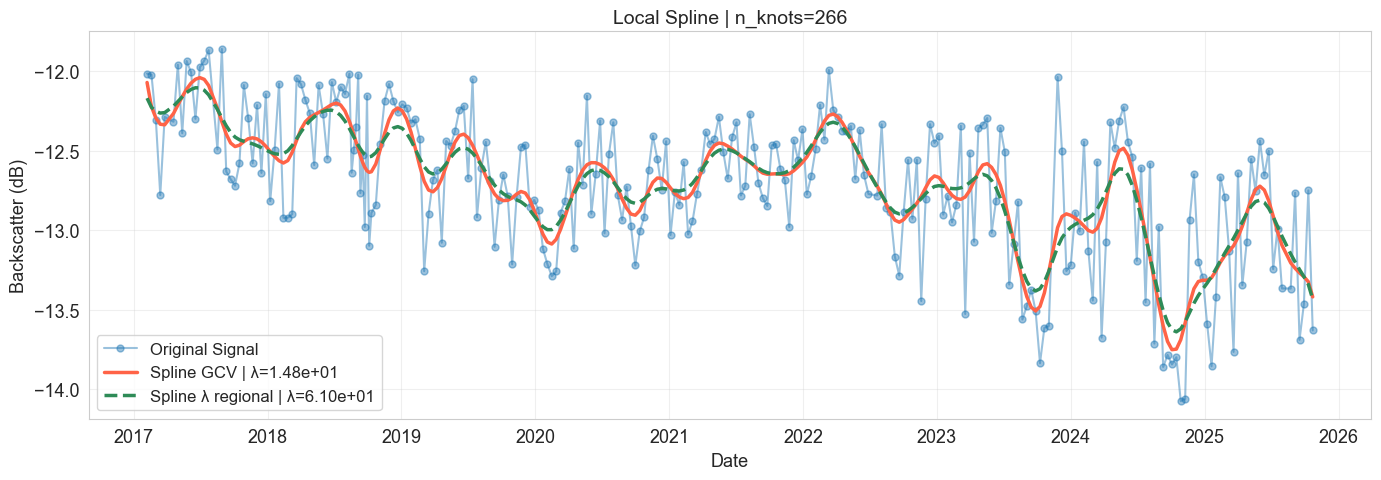

In [8]:
ts_defol_z1_vh     = extract_signal_local_log(subzone=1, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z1_vh = run_local_spline(ts_defol_z1_vh,lambda_regional_vh,std_regional_vh,condition_cgv=False)  

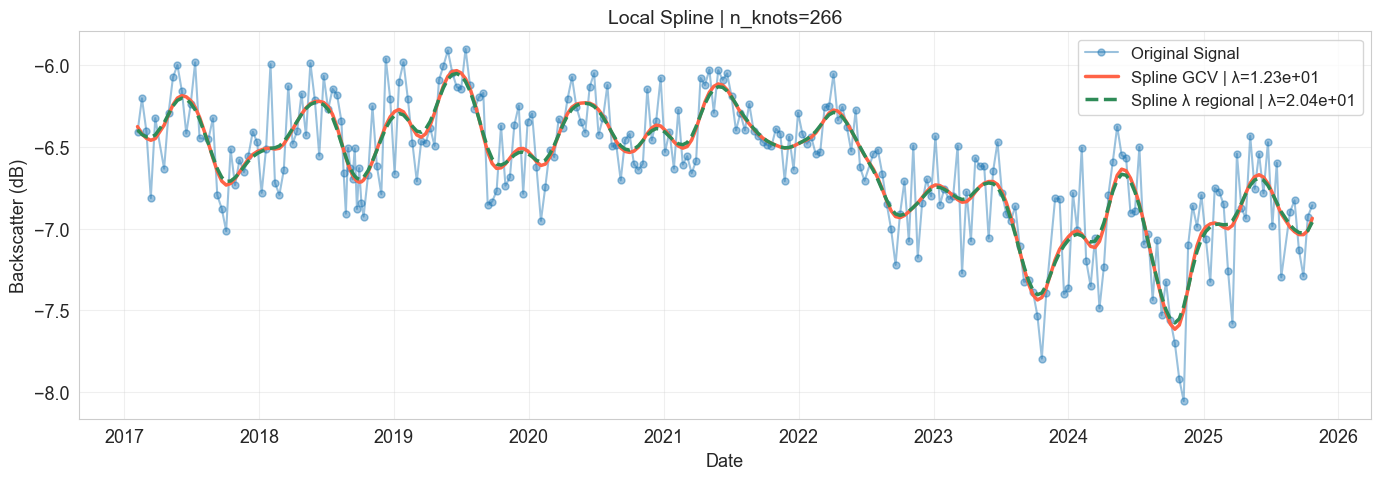

In [9]:
ts_defol_z1_vv     = extract_signal_local_log(subzone=1, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z1_vv = run_local_spline(ts_defol_z1_vv,lambda_regional_vv,std_regional_vv,condition_cgv=False)  

#### Zone 2

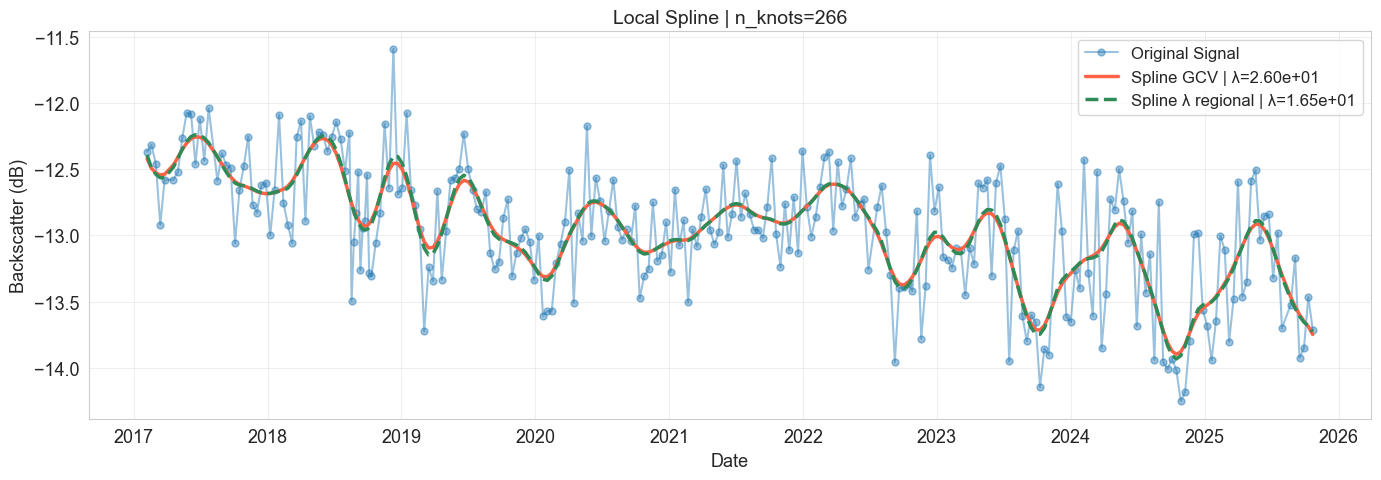

In [10]:
ts_defol_z2_vh     = extract_signal_local_log(subzone=2, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z2_vh = run_local_spline(ts_defol_z2_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

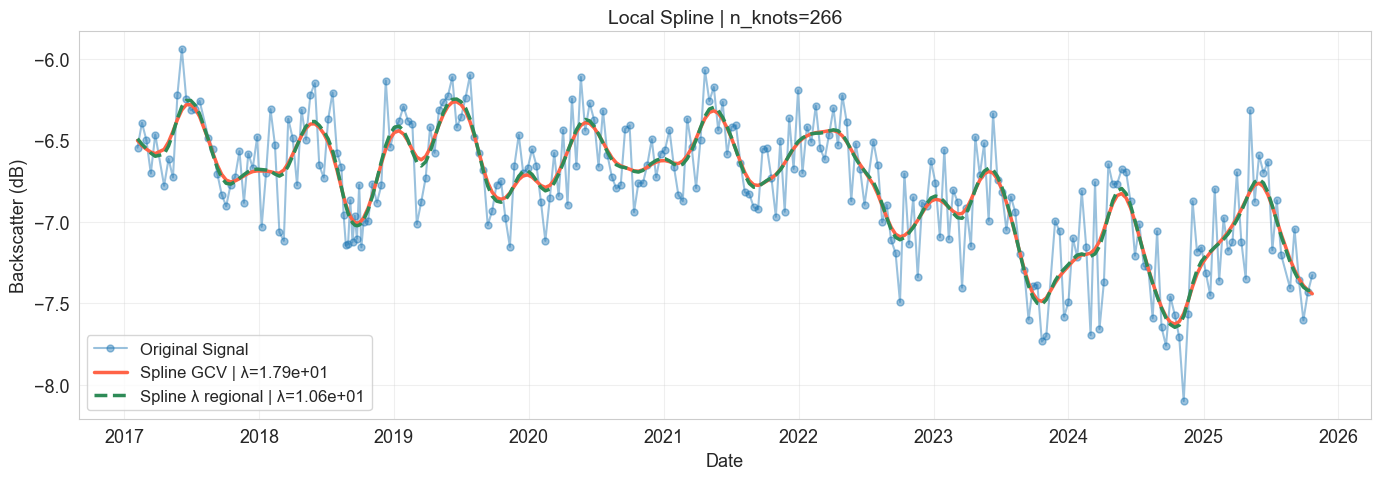

In [11]:
ts_defol_z2_vv     = extract_signal_local_log(subzone=2, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z2_vv = run_local_spline(ts_defol_z2_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 3

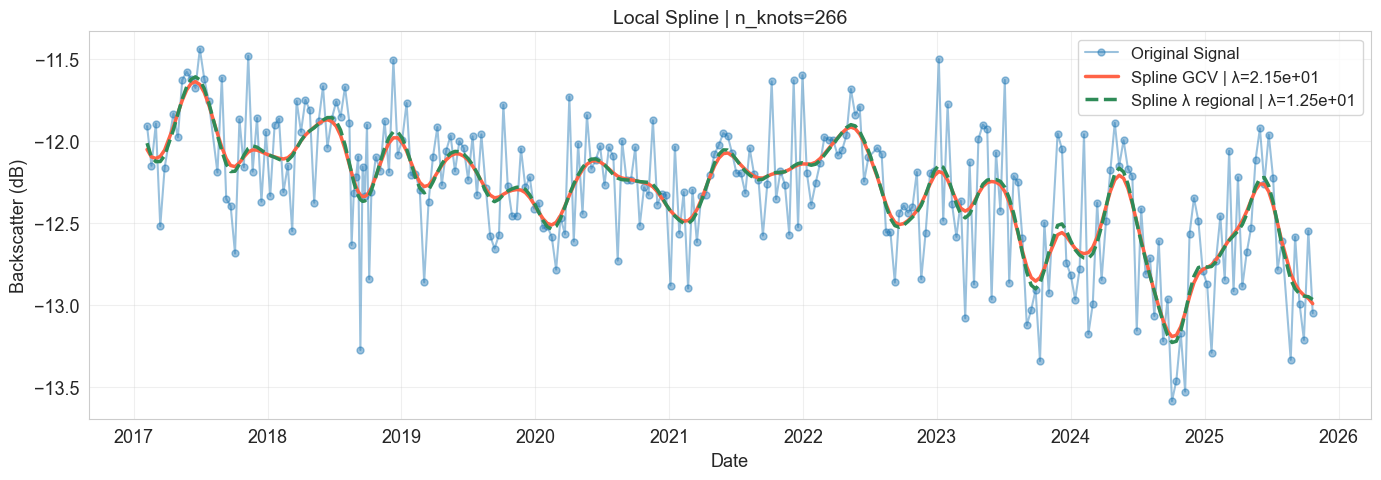

In [12]:
ts_defol_z3_vh     = extract_signal_local_log(subzone=3, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z3_vh = run_local_spline(ts_defol_z3_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

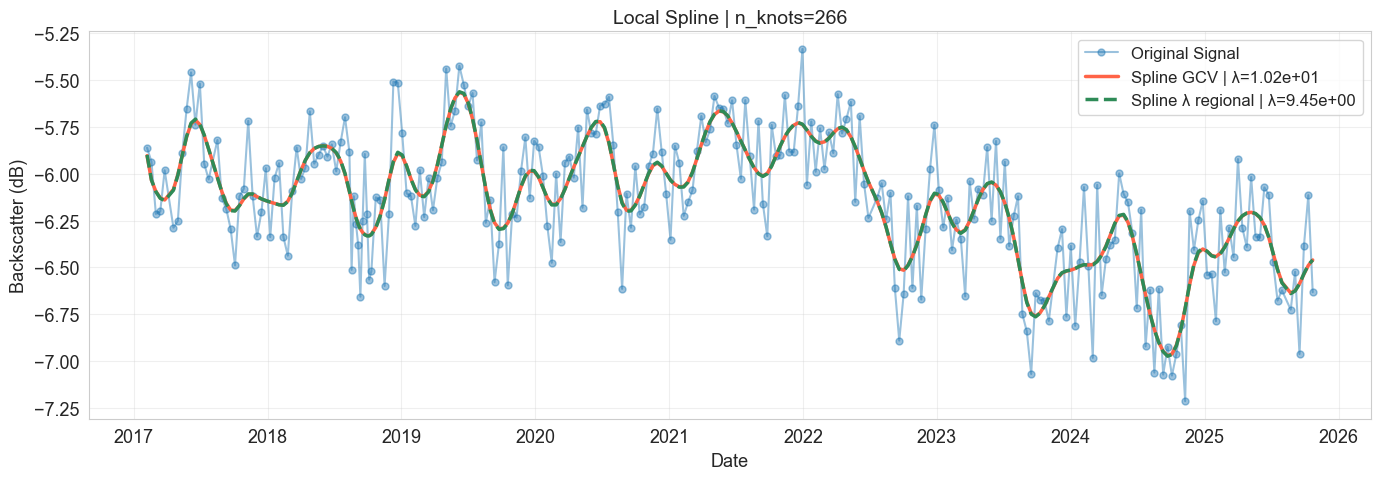

In [13]:
ts_defol_z3_vv     = extract_signal_local_log(subzone=3, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z3_vv = run_local_spline(ts_defol_z3_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 4

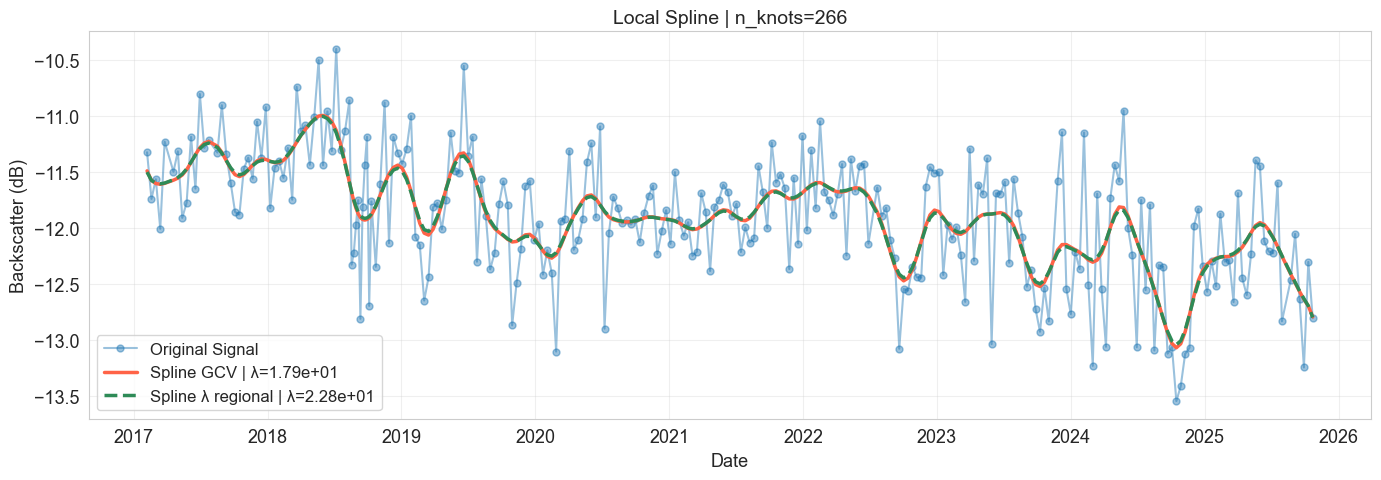

In [14]:
ts_defol_z4_vh     = extract_signal_local_log(subzone=4, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z4_vh = run_local_spline(ts_defol_z4_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

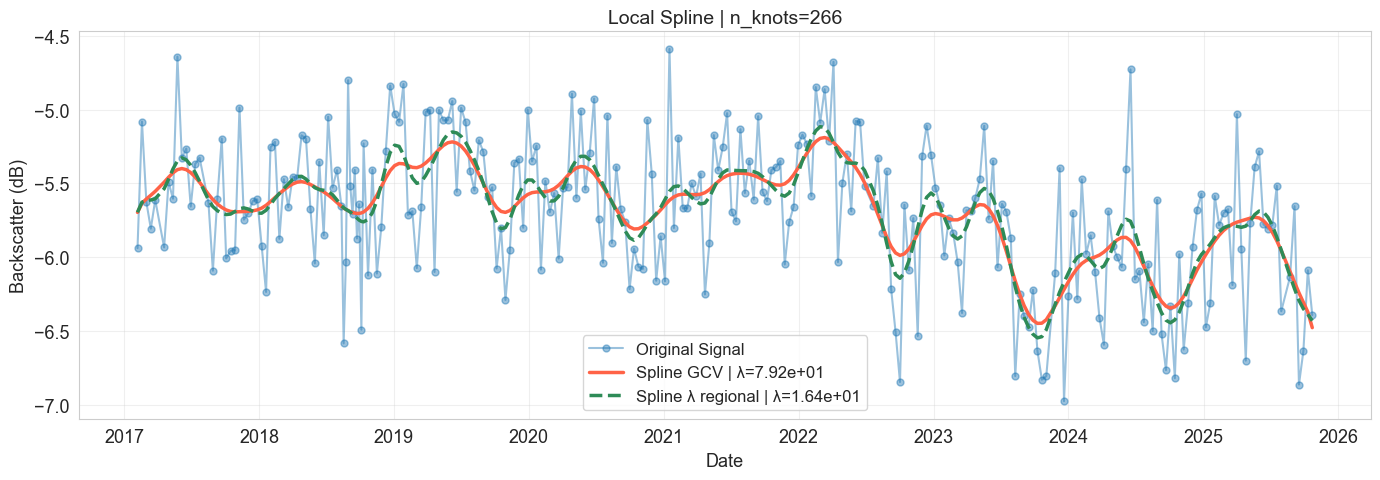

In [15]:
ts_defol_z4_vv     = extract_signal_local_log(subzone=4, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z4_vv = run_local_spline(ts_defol_z4_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 5

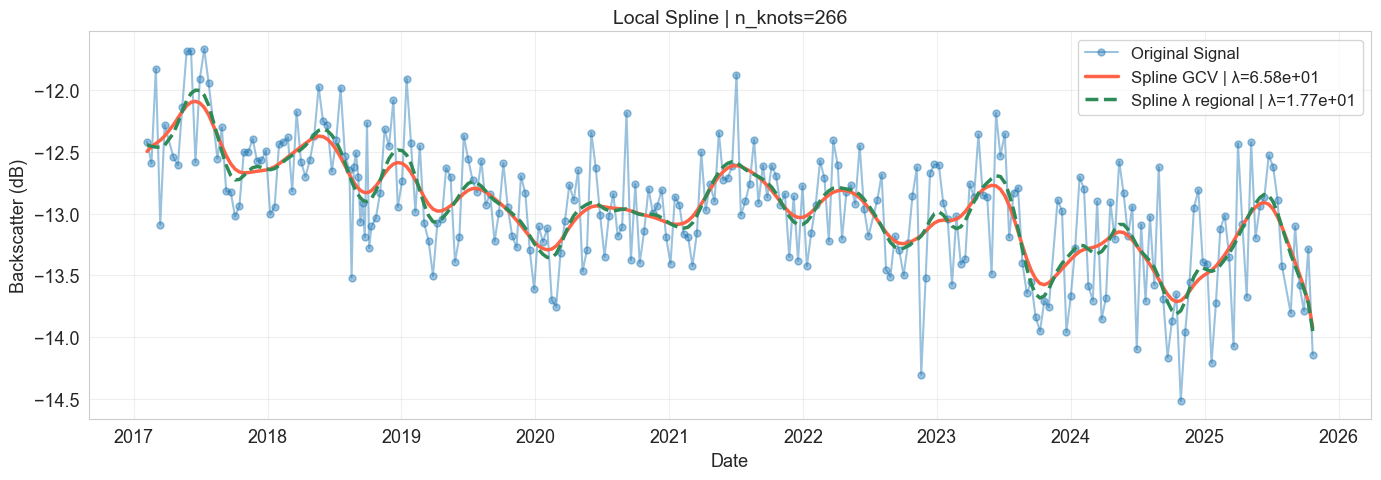

In [16]:
ts_defol_z5_vh     = extract_signal_local_log(subzone=5, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z5_vh = run_local_spline(ts_defol_z5_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

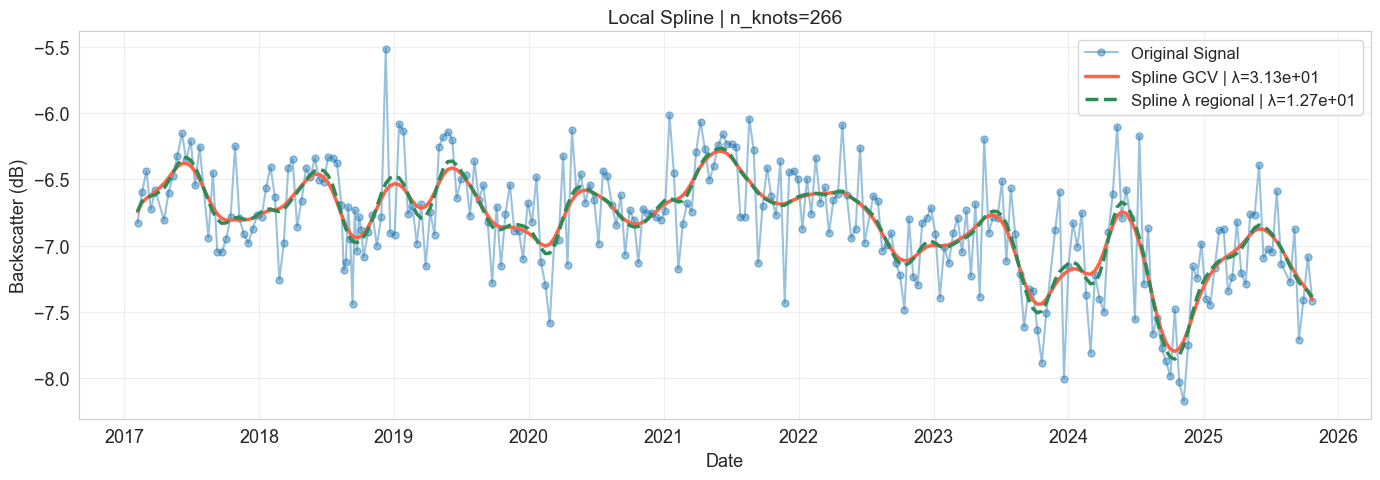

In [17]:
ts_defol_z5_vv     = extract_signal_local_log(subzone=5, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z5_vv = run_local_spline(ts_defol_z5_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 6

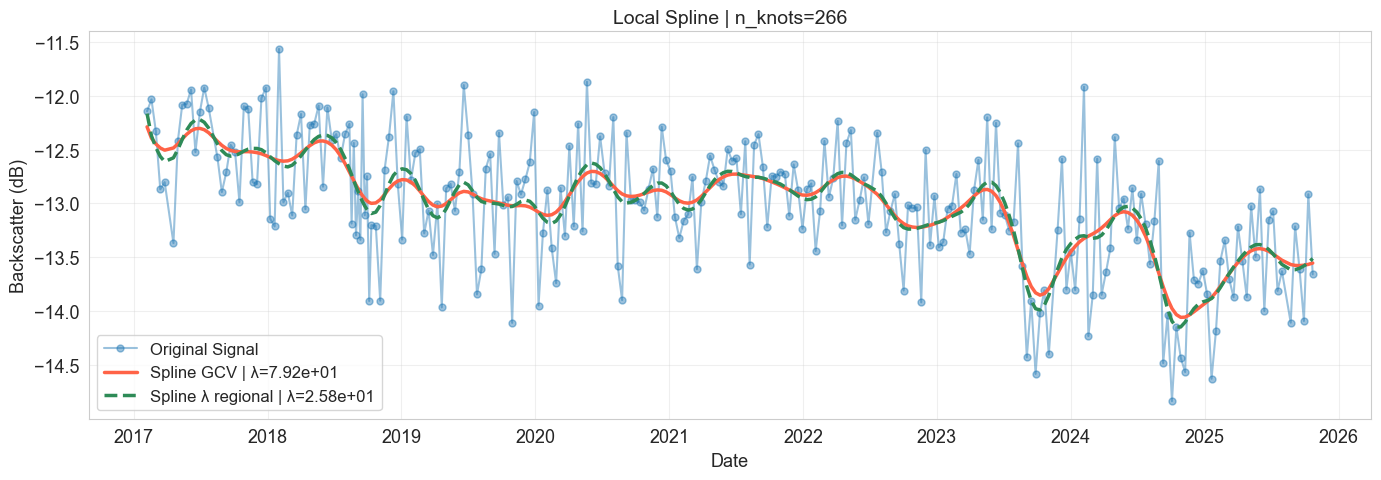

In [18]:
ts_defol_z6_vh     = extract_signal_local_log(subzone=6, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z6_vh = run_local_spline(ts_defol_z6_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

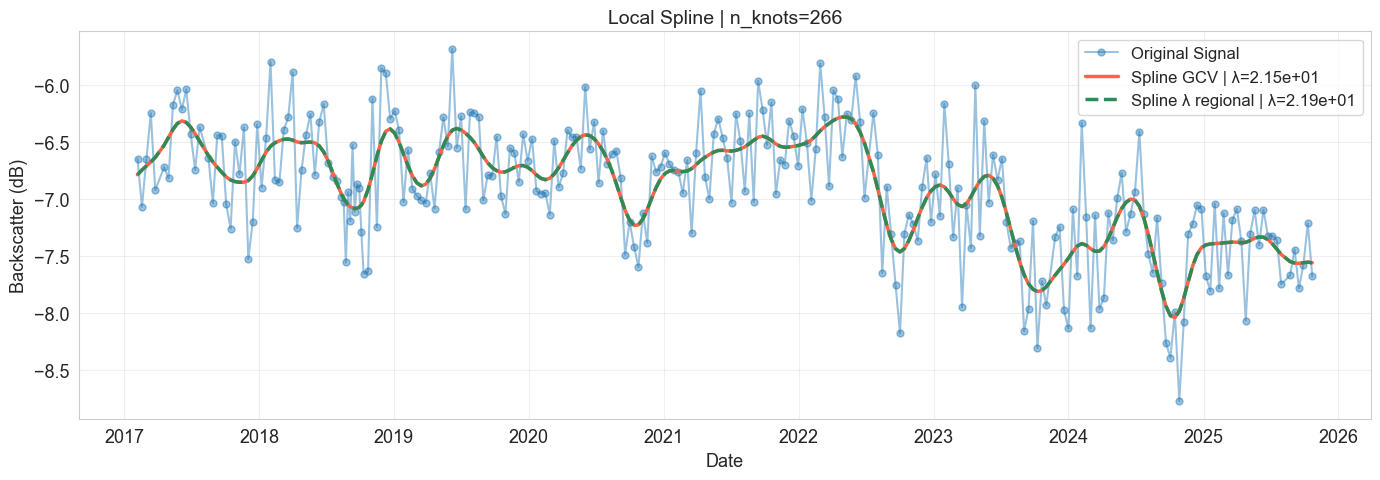

In [19]:
ts_defol_z6_vv     = extract_signal_local_log(subzone=6, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z6_vv = run_local_spline(ts_defol_z6_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 7

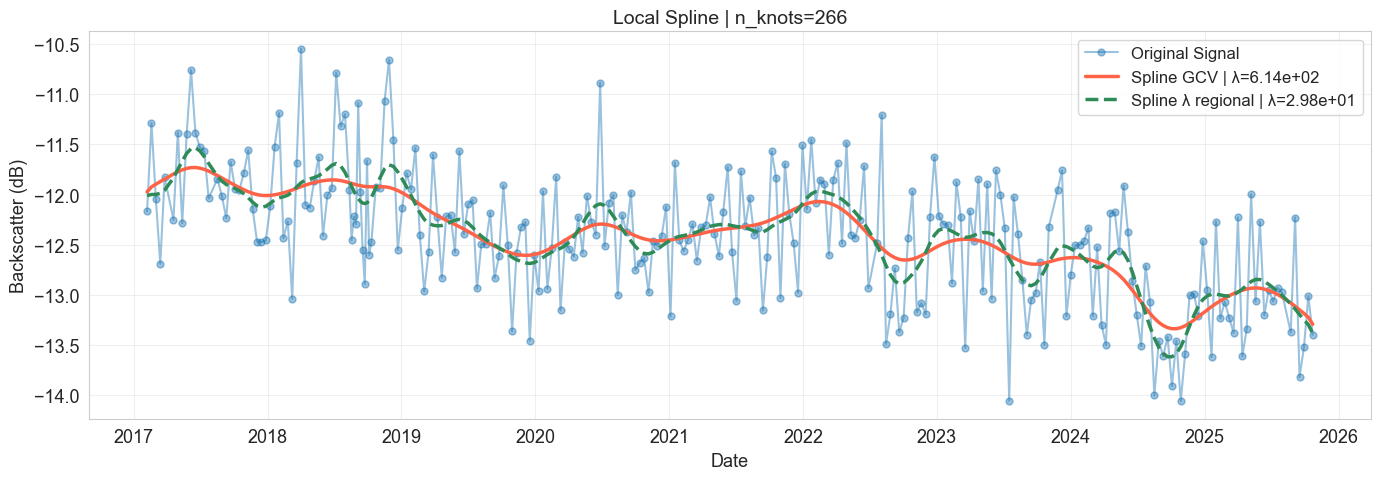

In [20]:
ts_defol_z7_vh     = extract_signal_local_log(subzone=7, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z7_vh = run_local_spline(ts_defol_z7_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

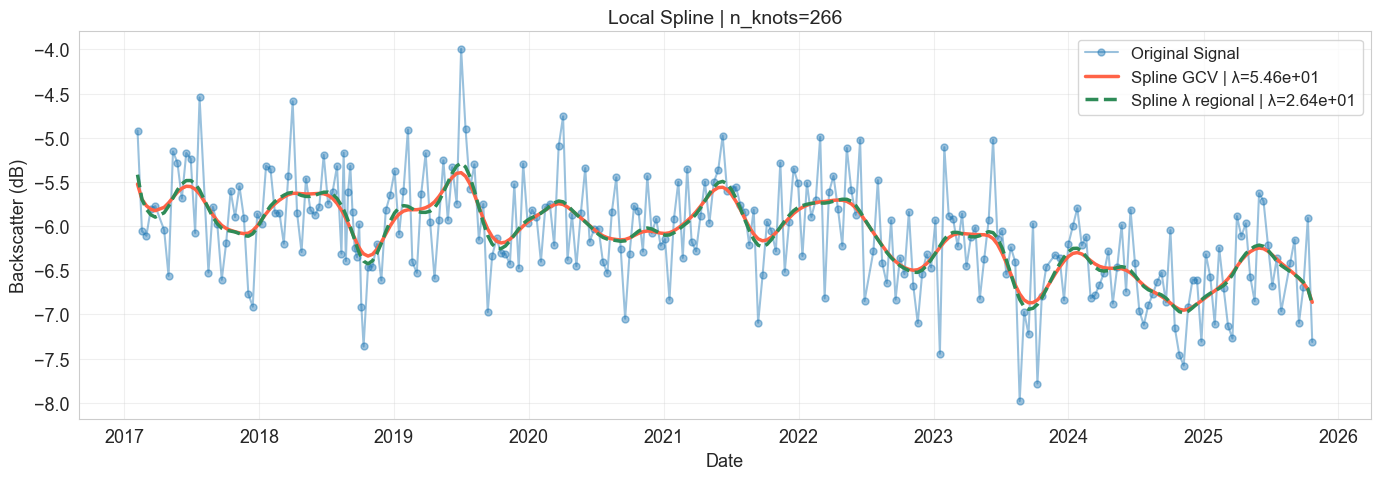

In [21]:
ts_defol_z7_vv     = extract_signal_local_log(subzone=7, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z7_vv = run_local_spline(ts_defol_z7_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 8

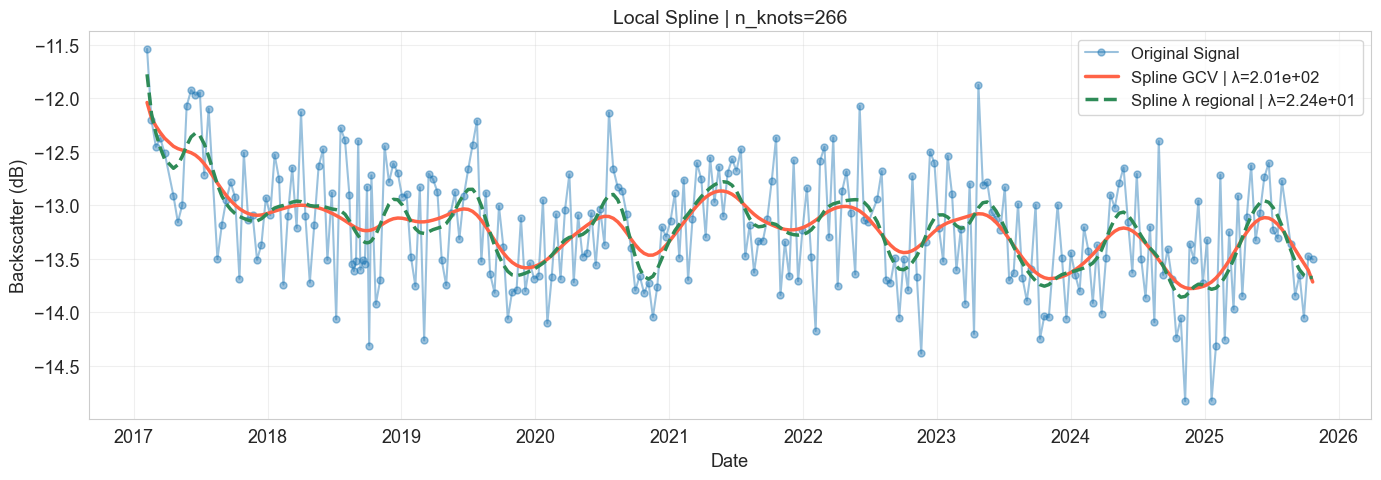

In [22]:
ts_defol_z8_vh     = extract_signal_local_log(subzone=8, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z8_vh = run_local_spline(ts_defol_z8_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

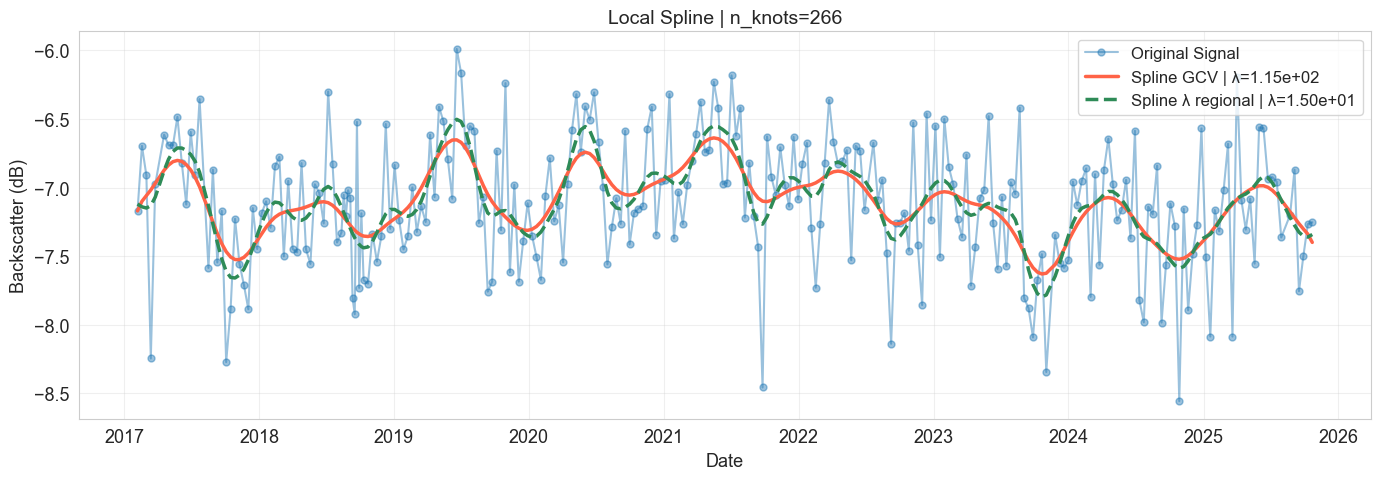

In [23]:
ts_defol_z8_vv     = extract_signal_local_log(subzone=8, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z8_vv = run_local_spline(ts_defol_z8_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 9

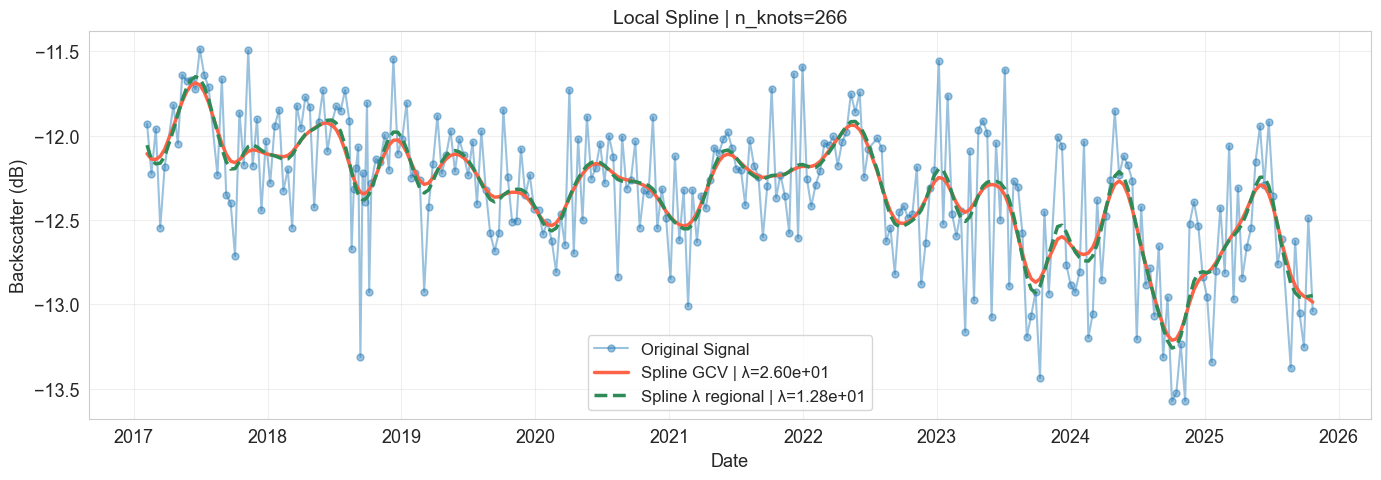

In [24]:
ts_defol_z9_vh     = extract_signal_local_log(subzone=9, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z9_vh = run_local_spline(ts_defol_z9_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

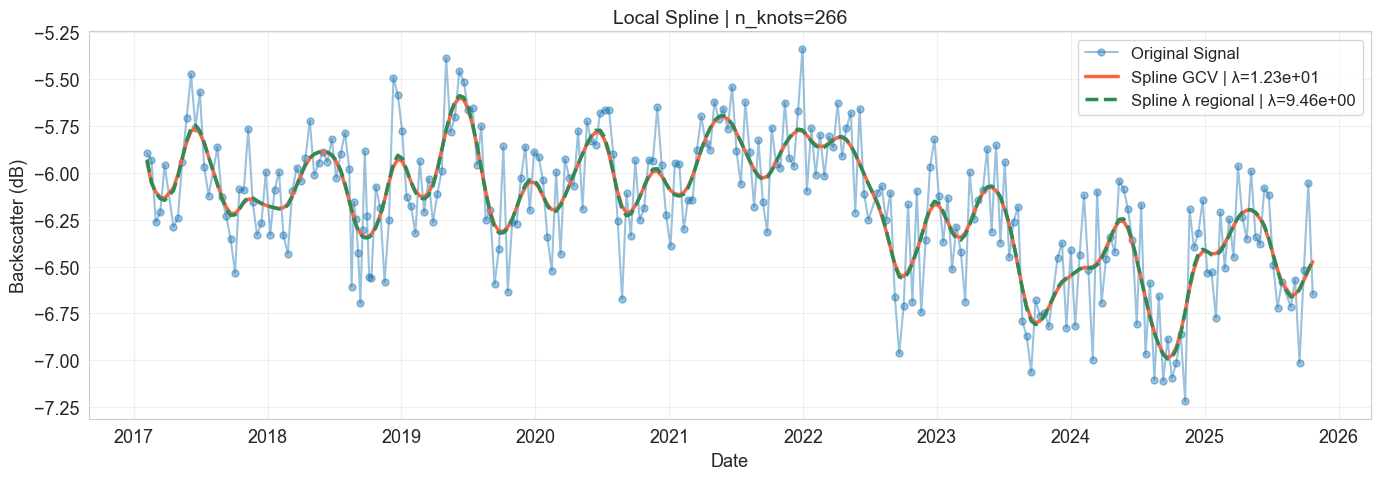

In [25]:
ts_defol_z9_vv     = extract_signal_local_log(subzone=9, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z9_vv = run_local_spline(ts_defol_z9_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

#### Zone 10

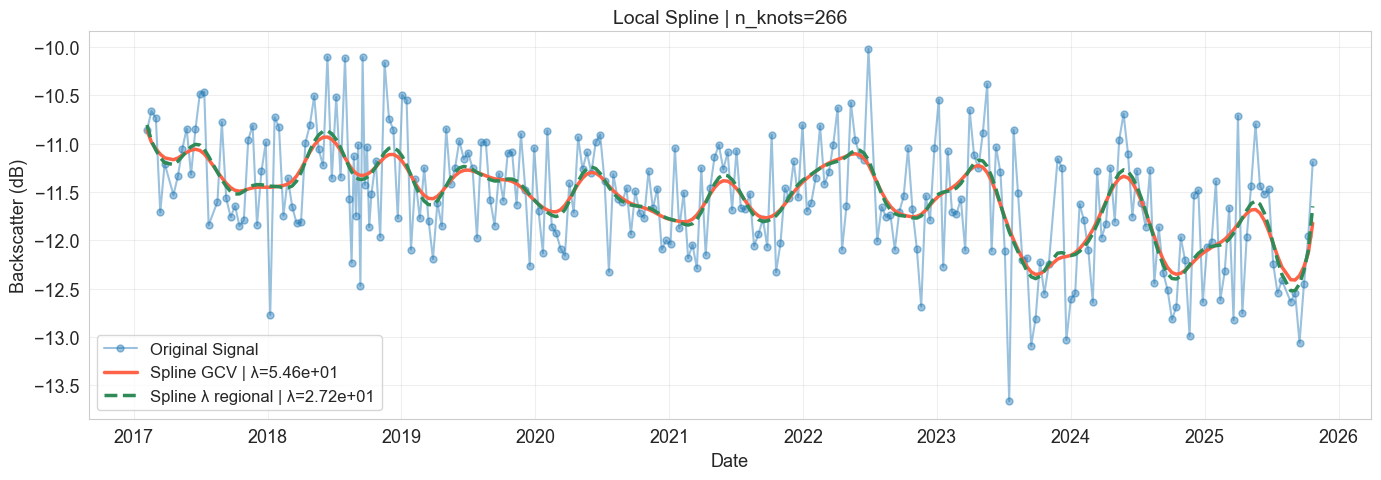

In [26]:
ts_defol_z10_vh     = extract_signal_local_log(subzone=10, type_veg="defol", polarization="vh", orbite=39, direction="DES")

result_local_z10_vh = run_local_spline(ts_defol_z10_vh,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  

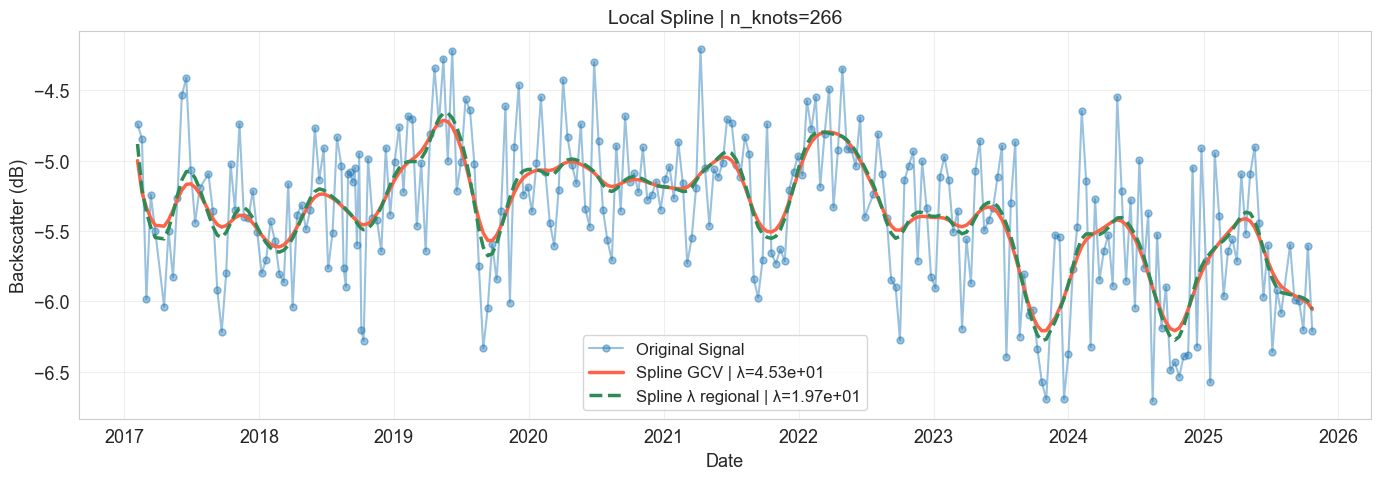

In [27]:
ts_defol_z10_vv     = extract_signal_local_log(subzone=10, type_veg="defol", polarization="vv", orbite=39, direction="DES")

result_local_z10_vv = run_local_spline(ts_defol_z10_vv,lambda_regional_zone1,std_regional_zone1,condition_cgv=False)  


# Cas de Paracou : Référence

## Données

In [28]:
FILEPATH_REF = {
    "vv": {
        "ASC": {
            "047": {
                "AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_ASC_047_allROI.csv",
                "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_ASC_047_TropiScat.csv"
            }
        },
        "DSC": {
            "039": {
                "AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_DSC_039_allROI.csv",
                "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vv_DSC_039_TropiScat.csv"
            }
        }
    },
    "vh": {
        "ASC": {
            "047": {
                "AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_ASC_047_allROI.csv",
                "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_ASC_047_TropiScat.csv"
            }
        },
        "DSC": {
            "039": {
                "AllROI": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_DSC_039_allROI.csv",
                "TropiScat": "data/Data/S1A_ASC-DSC_VV-VH_Paracou/s1a_vh_DSC_039_TropiScat.csv"
            }
        }
    }
}


   Paramètre        | Modalités Possibles                     |
 |------------------|-----------------------------------------|
 | polarization     | "vv", "vh"                              |
 | orbit            | "ASC", "DSC"                            |
 | relative_orbit   | "047", "039"                            |
 | region            | "AllROI", "TropiScat"                   |
 | masking           | "masked", "unmasked"                    |

In [29]:
def extract_signal_ref(polarization, orbit, region="AllROI"):
    """
    Extrait la série temporelle depuis les fichiers CSV S1A selon les paramètres donnés.

    Args:
        polarization (str): "vv" ou "vh"
        orbit (str): "ASC" ou "DSC"
        region (str): "AllROI" ou "TropiScat"

    Returns:
        pd.DataFrame: DataFrame avec les colonnes ["date", "mean_value"], triées par date
    """
    polarization = polarization.lower()
    orbit = orbit.upper()
    region = region if region in ["AllROI", "TropiScat"] else "AllROI"

    if polarization not in FILEPATH_REF:
        raise ValueError(f"polarization doit être 'vv' ou 'vh', reçu : '{polarization}'")
    if orbit not in FILEPATH_REF[polarization]:
        raise ValueError(f"orbit doit être 'ASC' ou 'DSC', reçu : '{orbit}'")

    # Détermination de relative_orbit en fonction de orbit
    relative_orbit = "047" if orbit == "ASC" else "039"

    if region not in FILEPATH_REF[polarization][orbit][relative_orbit]:
        raise ValueError(f"region doit être 'AllROI' ou 'TropiScat', reçu : '{region}'")

    file_path = FILEPATH_REF[polarization][orbit][relative_orbit][region]

    df = pd.read_csv(file_path)
    df["date"] = pd.to_datetime(df["time"])

    # Prendre directement la colonne 'value' comme 'mean_value'
    df = df[["date", "value"]].rename(columns={"value": "mean_value"})

    return df.sort_values("date").reset_index(drop=True)

## Régression Spline

### Régionale: AllROI

  n = 243
  n_knots fixed by number of points : 243



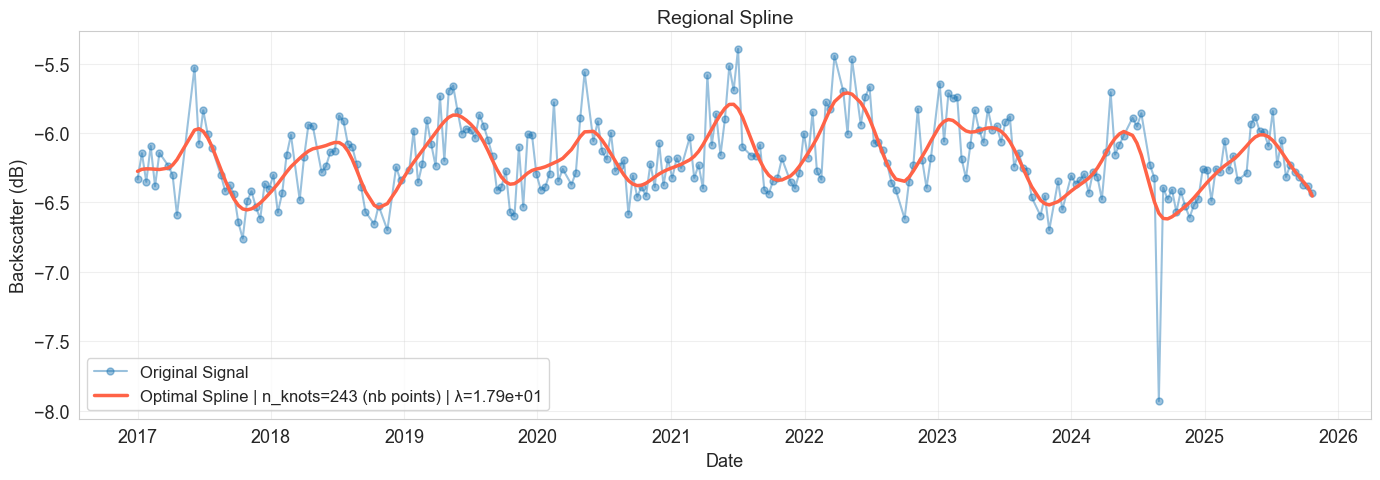

  n = 242
  n_knots fixed by number of points : 242



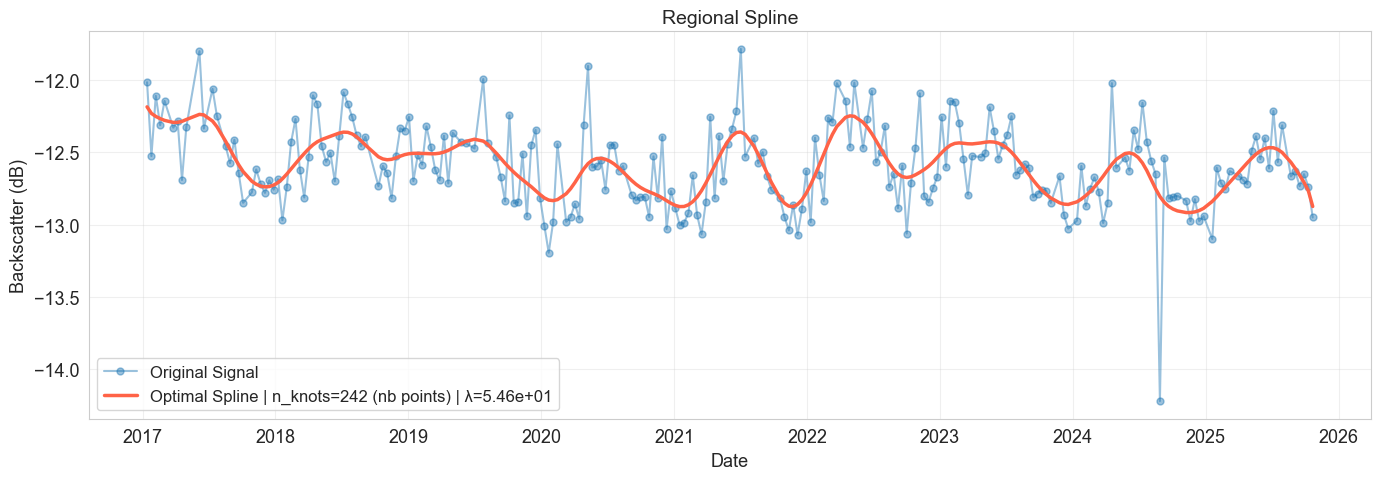

  n = 248
  n_knots fixed by number of points : 248



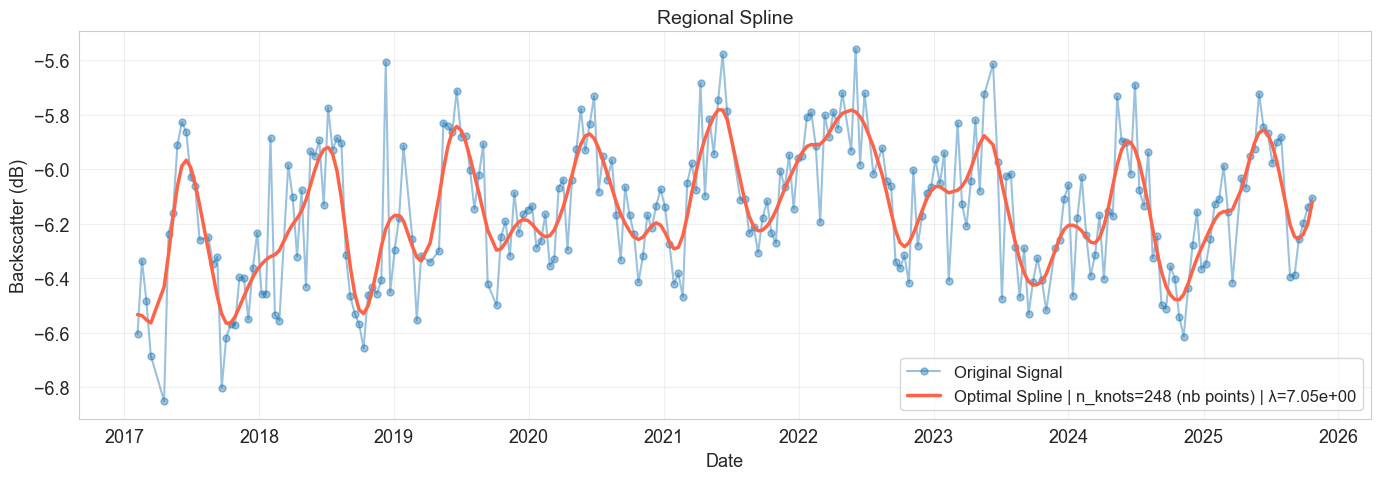

  n = 246
  n_knots fixed by number of points : 246



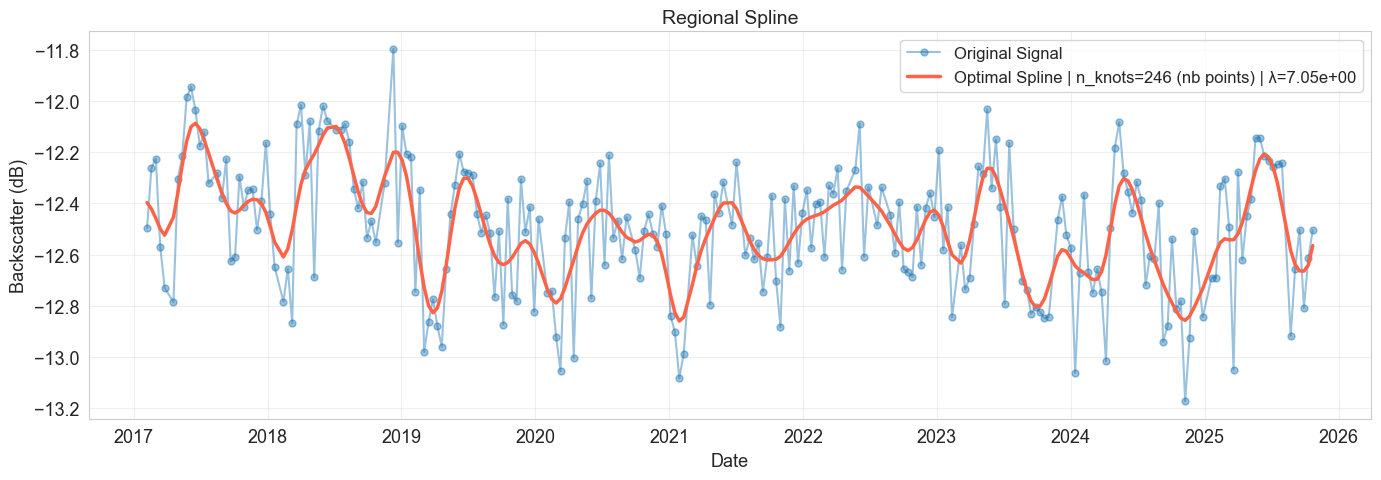

In [30]:
# Séries temporelles
## ASC
ts_allROI_asc_vv = extract_signal_ref(polarization="vv", orbit="ASC", region="AllROI")
ts_allROI_asc_vh = extract_signal_ref(polarization="vh", orbit="ASC", region="AllROI")
## DSC
ts_allROI_dsc_vv = extract_signal_ref(polarization="vv", orbit="DSC", region="AllROI")
ts_allROI_dsc_vh = extract_signal_ref(polarization="vh", orbit="DSC", region="AllROI")

# Spline
## ASC
result_allROI_asc_vv = run_regional_spline(ts_allROI_asc_vv,use_mallows=False)   
result_allROI_asc_vh = run_regional_spline(ts_allROI_asc_vh,use_mallows=False)   

##DSC
result_allROI_dsc_vv = run_regional_spline(ts_allROI_dsc_vv,use_mallows=False)  
result_allROI_dsc_vh = run_regional_spline(ts_allROI_dsc_vh,use_mallows=False)   


# paramètres pour regression locale
## ASC VV
lambda_allROI_asc_vv=result_allROI_asc_vv["lam"]
std_allROI_asc_vv= result_allROI_asc_vv["reg_std"]

## ASC VH
lambda_allROI_asc_vh=result_allROI_asc_vh["lam"]
std_allROI_asc_vh= result_allROI_asc_vh["reg_std"]

## DSC VH
lambda_allROI_dsc_vh=result_allROI_dsc_vh["lam"]
std_allROI_dsc_vh= result_allROI_dsc_vh["reg_std"]

## DSC VV
lambda_allROI_dsc_vv=result_allROI_dsc_vv["lam"]
std_allROI_dsc_vv= result_allROI_dsc_vv["reg_std"]



### Locale: Tropiscat

#### Cas de VV ASC

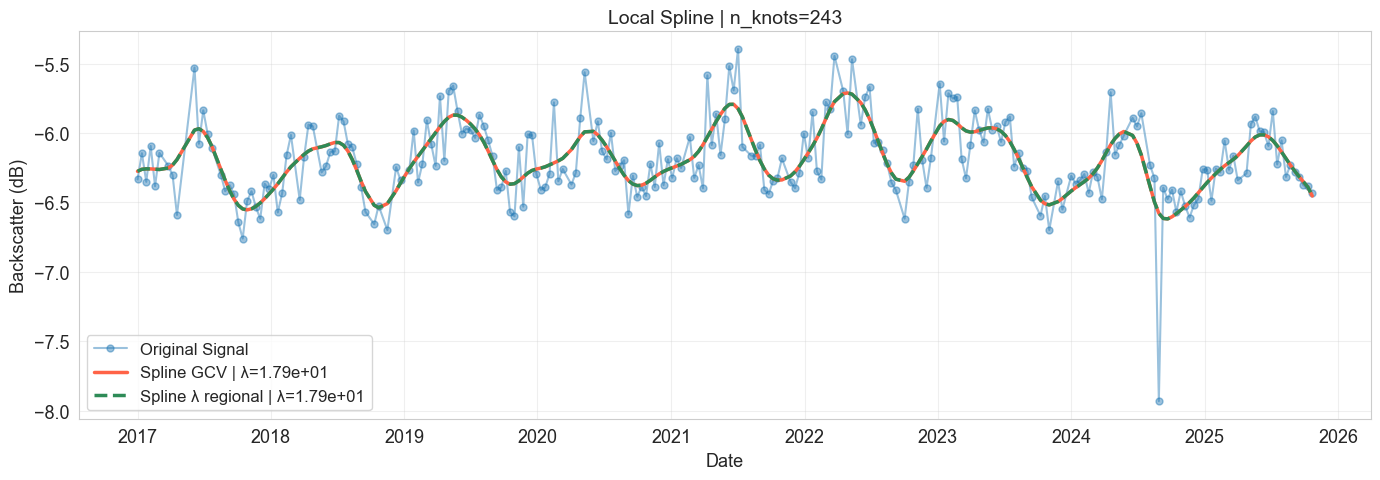

In [31]:
ts_Trop_asc_vv     = extract_signal_ref(polarization="vv", orbit="ASC", region="Tropiscat")

result_Trop_asc_vv = run_local_spline(ts_Trop_asc_vv,lambda_allROI_asc_vv,std_allROI_asc_vv,condition_cgv=False)  

#### Cas de VH ASC

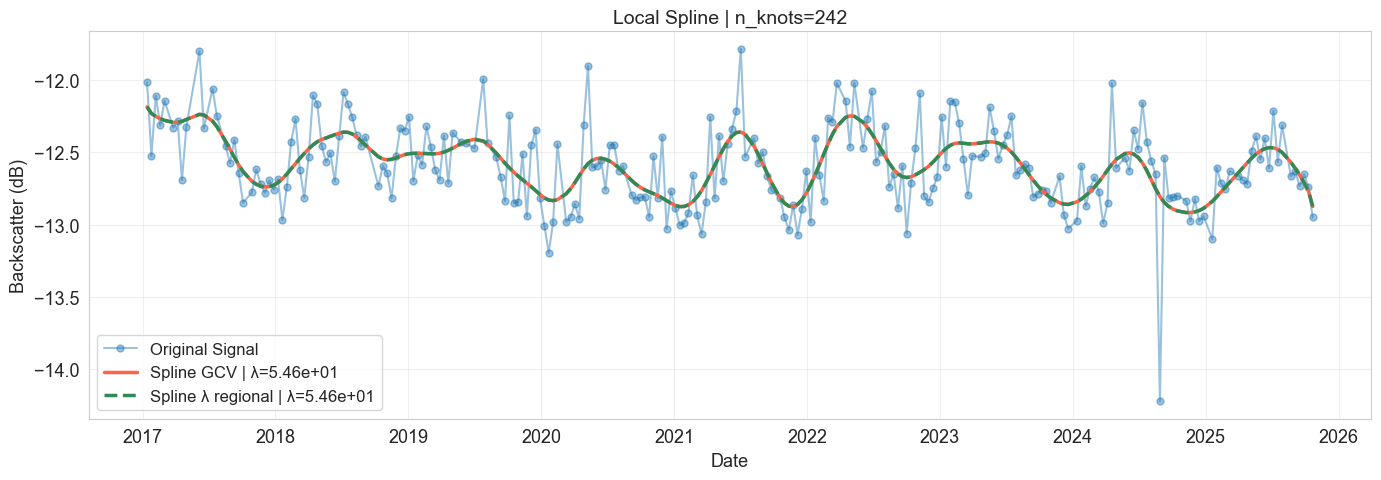

In [32]:
ts_Trop_asc_vh     = extract_signal_ref(polarization="vh", orbit="ASC", region="Tropiscat")

result_Trop_asc_vh = run_local_spline(ts_Trop_asc_vh,lambda_allROI_asc_vh,std_allROI_asc_vh,condition_cgv=False)  

#### Cas de VV DSC

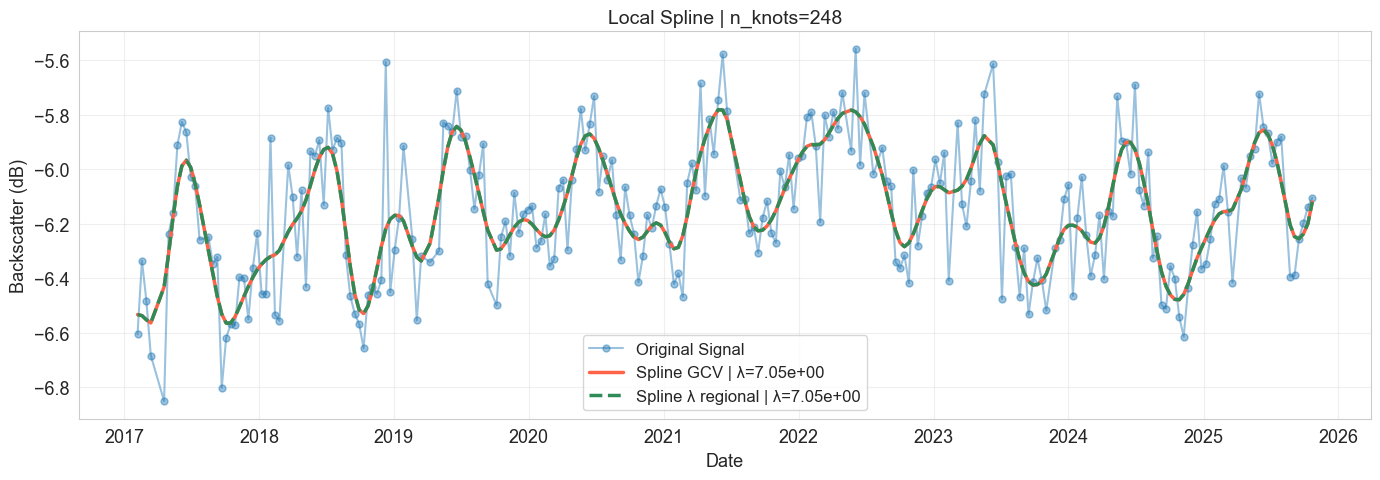

In [33]:
ts_Trop_dsc_vv     = extract_signal_ref(polarization="vv", orbit="DSC", region="Tropiscat")

result_Trop_dsc_vv = run_local_spline(ts_Trop_dsc_vv,lambda_allROI_dsc_vv,std_allROI_dsc_vv,condition_cgv=False)  

#### Cas de VH DSC

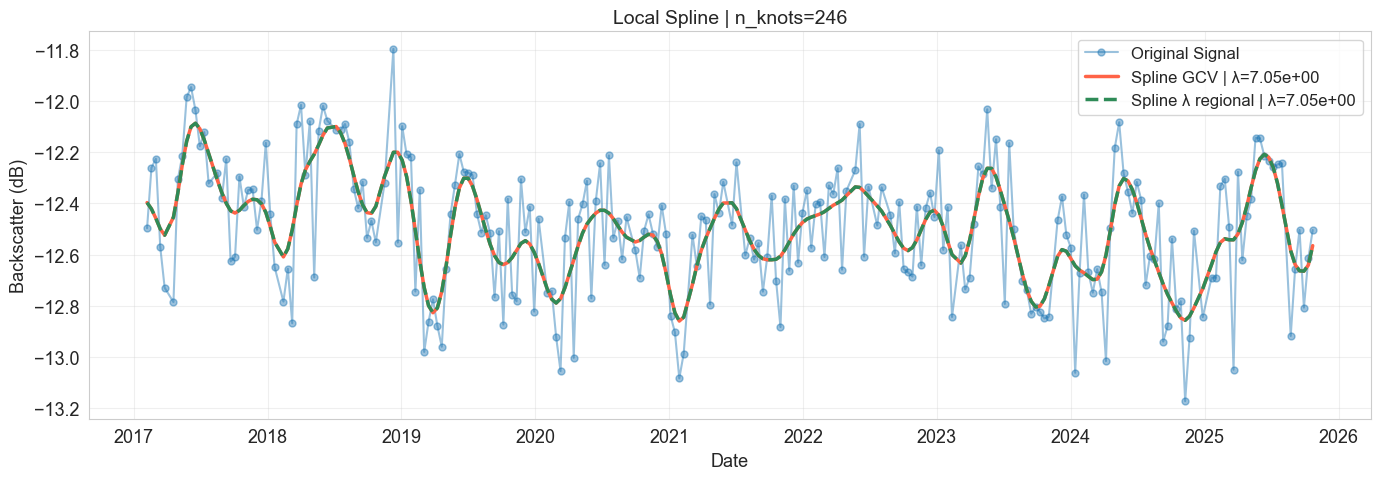

In [34]:
ts_Trop_dsc_vh     = extract_signal_ref(polarization="vh", orbit="DSC", region="Tropiscat")

result_Trop_dsc_vh = run_local_spline(ts_Trop_dsc_vh,lambda_allROI_dsc_vh,std_allROI_dsc_vh,condition_cgv=False)  